# Week 3 — Feature Selection and Component Regression

**Integrated Capstone Project: Breast Cancer (two datasets)**

### Notebook purpose
This notebook applies the Week 3 concepts- **forward selection, backward selection, principal component regression (PCR), and partial least squares regression (PLSR)** - to the two breast cancer datasets I use throughout my capstone:

1. **Breast Cancer Wisconsin (Diagnostic)** - tumor morphology measurements from images (radius, texture, perimeter, area, smoothness, concavity).
2. **Breast Cancer Coimbra** -  clinical, anthropometric, and blood-based biomarkers (age, BMI, glucose, insulin, HOMA, leptin, adiponectin, resistin, MCP-1).

I run the same Week 3 methods on each dataset so I can compare how feature selection and component-based methods behave on two very different kinds of healthcare data. I do not merge the datasets, because they contain different patients and different variables; I analyze each separately and compare at the end.

### Project question
> To what extent can measurable patient and tumor characteristics help distinguish breast cancer cases from non-cancer cases?

### Modeling choice
Both outcomes are categorical, so I use linear regression as an exploratory **linear probability model** (predicted scores clipped to 0–1). This is not the final clinical model — later weeks use logistic regression, SVMs, decision trees, and random forests. For Week 3, this lets me focus on selecting and summarizing predictors.

The models compared in each part are:
1. Baseline linear regression using all features
2. Forward selection
3. Backward selection
4. Principal component regression (PCR)
5. Partial least squares regression (PLSR)

### Roadmap
- **Part 1** — Breast Cancer Wisconsin analysis
- **Part 2** — Breast Cancer Coimbra analysis
- **Part 3** — Comparison and overall Week 3 conclusions
- **References**

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Dataset
from sklearn.datasets import load_breast_cancer
# Modeling and preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, recall_score, precision_score
# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)


## Part 1 — Breast Cancer Wisconsin (Diagnostic)

This dataset is loaded from `sklearn.datasets.load_breast_cancer`. It contains 30 tumor measurements computed from digitized images, with each tumor labeled benign or malignant. The libraries imported above cover loading, scaling, feature selection, PCR, PLSR, and evaluation.

### 1.1 Load and prepare the data

Load and prepare the dataset

The sklearn version of the dataset uses:

- `0 = malignant`
- `1 = benign`

For my notebook, I create a new variable where:

- `diagnosis_malignant = 1` means malignant
- `diagnosis_malignant = 0` means benign

I am doing this because it makes the interpretation easier. Higher predicted values mean the model predicts a higher likelihood of malignancy.

In [2]:
# Load the Breast Cancer Wisconsin Diagnostic dataset
cancer = load_breast_cancer()
# Create dataframe
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
# Clean column names
df.columns = df.columns.str.replace(" ", "_")
# Create target variable
df["diagnosis_malignant"] = (cancer.target == 0).astype(int)
df["diagnosis_label"] = np.where(df["diagnosis_malignant"] == 1, "Malignant", "Benign")
print("Dataset shape:", df.shape)
print("\nDiagnosis counts:")
print(df["diagnosis_label"].value_counts())
df.head()


Dataset shape: (569, 32)

Diagnosis counts:
diagnosis_label
Benign       357
Malignant    212
Name: count, dtype: int64


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,diagnosis_malignant,diagnosis_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1,Malignant


### 1.2 Features and target

The original dataset has 30 tumor measurement features. These include mean, standard error, and worst values for features such as radius, texture, perimeter, area, smoothness, compactness, concavity, and symmetry.

For Week 3, I will compare:

1. A baseline model using all features  
2. Forward selection  
3. Backward selection  
4. Principal Component Regression  
5. Partial Least Squares Regression

In [3]:
target_col = "diagnosis_malignant"
label_col = "diagnosis_label"
feature_cols = [col for col in df.columns if col not in [target_col, label_col]]
X = df[feature_cols]
y = df[target_col]
print("Number of rows:", X.shape[0])
print("Number of features:", X.shape[1])


Number of rows: 569
Number of features: 30


### 1.3 Exploratory analysis

Before modeling, I want to remind myself why Week 3 methods are useful. In this dataset, many predictors are related to each other. For example, radius, perimeter, and area are all describing tumor size.

Forward and backward selection can help choose a smaller group of useful variables. PCR and PLSR can help when there is multicollinearity because they reduce the predictors into components.

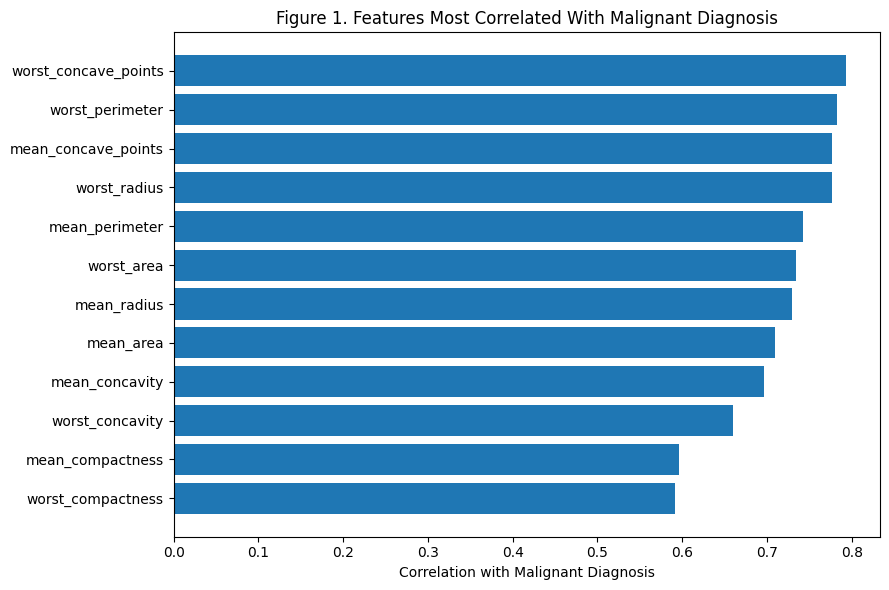

,feature,correlation_with_malignant
0,worst_compactness,0.590998
1,mean_compactness,0.596534
2,worst_concavity,0.659610
3,mean_concavity,0.696360
4,mean_area,0.708984
5,mean_radius,0.730029
6,worst_area,0.733825
7,mean_perimeter,0.742636
8,worst_radius,0.776454
9,mean_concave_points,0.776614


In [4]:
# Figure 1: Top correlations with malignant diagnosis
corr_with_target = df[feature_cols + [target_col]].corr()[target_col].drop(target_col)
top_corr = corr_with_target.abs().sort_values(ascending=False).head(12)
top_corr_signed = corr_with_target.loc[top_corr.index].sort_values()
plt.figure(figsize=(9, 6))
plt.barh(top_corr_signed.index, top_corr_signed.values)
plt.xlabel("Correlation with Malignant Diagnosis")
plt.title("Figure 1. Features Most Correlated With Malignant Diagnosis")
plt.tight_layout()
plt.show()
pd.DataFrame({
    "feature": top_corr_signed.index,
    "correlation_with_malignant": top_corr_signed.values
})


#### EDA note

This figure helps me see which features may be useful before model selection. If the strongest variables are mostly size and shape related, that supports what I found in earlier weeks. However, correlation with the target does not automatically mean every variable should stay in the model, especially when many variables are similar to each other.

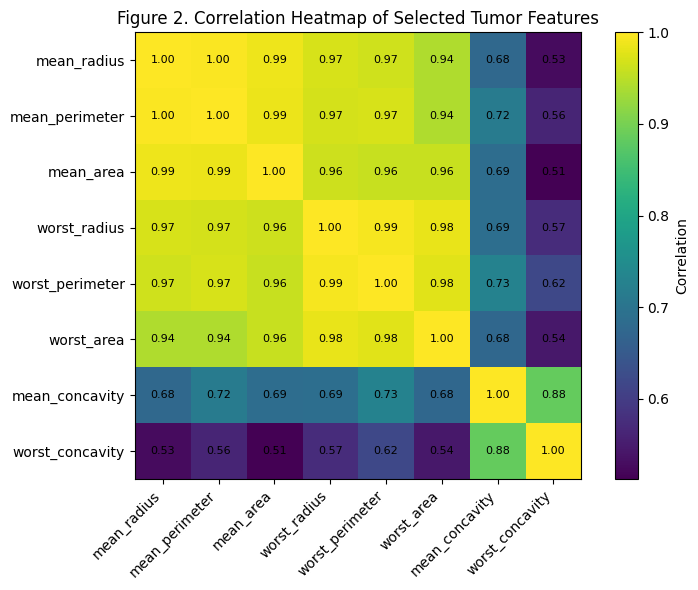

In [5]:
# Figure 2: Correlation heatmap for a smaller group of size-related features
size_features = [
    "mean_radius", "mean_perimeter", "mean_area",
    "worst_radius", "worst_perimeter", "worst_area",
    "mean_concavity", "worst_concavity"
]
corr = df[size_features].corr()
plt.figure(figsize=(8, 6))
plt.imshow(corr)
plt.colorbar(label="Correlation")
plt.xticks(range(len(size_features)), size_features, rotation=45, ha="right")
plt.yticks(range(len(size_features)), size_features)
plt.title("Figure 2. Correlation Heatmap of Selected Tumor Features")
for i in range(len(size_features)):
    for j in range(len(size_features)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.tight_layout()
plt.show()


#### Multicollinearity note

The heatmap shows why feature selection and component methods are useful here. If several features are highly correlated, a normal linear regression model may have unstable coefficients. The model may perform well, but it can be hard to explain which individual variable is actually responsible.

### 1.4 Train-test split

I split the data into training and testing sets. I use stratification because I want the benign and malignant proportions to stay similar in both sets.

This helps me check if the model performs well on new data instead of only fitting the training data.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))
print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))


Training shape: (455, 30)
Testing shape: (114, 30)

Training target distribution:
diagnosis_malignant
0    0.626374
1    0.373626
Name: proportion, dtype: float64

Testing target distribution:
diagnosis_malignant
0    0.631579
1    0.368421
Name: proportion, dtype: float64


### 1.5 Evaluation functions

The main metric I use is **RMSE** because I am treating this as a regression-style linear probability model. Lower RMSE means the predicted malignant score is closer to the actual 0/1 diagnosis.

I also include:

- MAE
- R²
- Accuracy using a 0.50 threshold
- Recall for malignant cases
- Precision for malignant cases

For a healthcare project, recall for malignant cases matters because missing a malignant case would be more concerning than many other types of errors.

In [7]:
def evaluate_predictions(y_true, y_pred):
    """Evaluate regression predictions and classification-style threshold results."""
    y_pred_clipped = np.clip(y_pred, 0, 1)
    y_class = (y_pred_clipped >= 0.50).astype(int)
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred_clipped)),
        "MAE": mean_absolute_error(y_true, y_pred_clipped),
        "R2": r2_score(y_true, y_pred_clipped),
        "accuracy_at_0.5": accuracy_score(y_true, y_class),
        "recall_malignant_at_0.5": recall_score(y_true, y_class, pos_label=1),
        "precision_malignant_at_0.5": precision_score(y_true, y_class, pos_label=1)
    }
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    """Fit a model and return train/test results."""
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_metrics = evaluate_predictions(y_train, train_pred)
    test_metrics = evaluate_predictions(y_test, test_pred)
    results = {
        "model": name,
        "train_RMSE": train_metrics["RMSE"],
        "test_RMSE": test_metrics["RMSE"],
        "train_MAE": train_metrics["MAE"],
        "test_MAE": test_metrics["MAE"],
        "train_R2": train_metrics["R2"],
        "test_R2": test_metrics["R2"],
        "accuracy_at_0.5": test_metrics["accuracy_at_0.5"],
        "recall_malignant_at_0.5": test_metrics["recall_malignant_at_0.5"],
        "precision_malignant_at_0.5": test_metrics["precision_malignant_at_0.5"]
    }
    return results, np.clip(train_pred, 0, 1), np.clip(test_pred, 0, 1)


### 1.6 Baseline linear regression (all features)

I start with a regular linear regression model using all 30 features. This gives me a baseline to compare against the Week 3 methods.

I use scaling because the tumor features are on very different scales.

In [8]:
baseline_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
baseline_results, baseline_train_pred, baseline_test_pred = evaluate_model(
    "Baseline Linear Regression: All Features",
    baseline_model,
    X_train,
    X_test,
    y_train,
    y_test
)
pd.DataFrame([baseline_results])


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_malignant_at_0.5,precision_malignant_at_0.5
0,Baseline Linear Regression: All Features,0.210002,0.230524,0.140449,0.156241,0.811559,0.771619,0.964912,0.904762,1.0


#### Baseline note

The baseline model is important because if a feature selection method gives similar performance with fewer variables, that may be better for interpretation. If PCR or PLSR gives similar performance with fewer components, that may show that the dataset has redundancy.

### 1.7 Forward selection

Forward selection starts with no predictors and adds one feature at a time. At each step, it picks the feature that gives the best cross-validated RMSE.

I like forward selection because it feels intuitive: start simple, then only add features if they help.

To avoid selecting too many features, I stop after 10 features. This is not the only possible stopping rule, but it keeps the model simpler and easier to explain.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
def cv_rmse_for_features(feature_list, X_data, y_data, cv):
    """Return mean cross-validated RMSE for a set of features."""
    model = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])
    scores = cross_val_score(
        model,
        X_data[feature_list],
        y_data,
        cv=cv,
        scoring="neg_mean_squared_error"
    )
    rmse_scores = np.sqrt(-scores)
    return rmse_scores.mean()
def forward_selection(X_data, y_data, max_features=10, cv=None):
    remaining_features = list(X_data.columns)
    selected_features = []
    history = []
    for step in range(max_features):
        candidate_results = []
        for feature in remaining_features:
            trial_features = selected_features + [feature]
            mean_rmse = cv_rmse_for_features(trial_features, X_data, y_data, cv)

            candidate_results.append({
                "step": step + 1,
                "feature_added": feature,
                "features": trial_features,
                "CV_RMSE": mean_rmse
            })
        candidate_df = pd.DataFrame(candidate_results).sort_values("CV_RMSE")
        best_row = candidate_df.iloc[0]
        selected_features = best_row["features"]
        remaining_features.remove(best_row["feature_added"])
        history.append({
            "step": step + 1,
            "feature_added": best_row["feature_added"],
            "selected_features": selected_features.copy(),
            "CV_RMSE": best_row["CV_RMSE"]
        })
    return pd.DataFrame(history)
forward_history = forward_selection(X_train, y_train, max_features=10, cv=cv)
forward_history


,step,feature_added,selected_features,CV_RMSE
0,1,worst_concave_points,[worst_concave_points],0.298930
1,2,worst_radius,"[worst_concave_points, worst_radius]",0.271936
2,3,worst_texture,"[worst_concave_points, worst_radius, worst_tex...",0.264047
3,4,worst_area,"[worst_concave_points, worst_radius, worst_tex...",0.259182
4,5,worst_smoothness,"[worst_concave_points, worst_radius, worst_tex...",0.253676
5,6,radius_error,"[worst_concave_points, worst_radius, worst_tex...",0.249954
6,7,worst_symmetry,"[worst_concave_points, worst_radius, worst_tex...",0.248255
7,8,compactness_error,"[worst_concave_points, worst_radius, worst_tex...",0.247327
8,9,area_error,"[worst_concave_points, worst_radius, worst_tex...",0.245954
9,10,worst_concavity,"[worst_concave_points, worst_radius, worst_tex...",0.245182


In [10]:
# Best forward-selection model based on lowest CV RMSE
best_forward_row = forward_history.sort_values("CV_RMSE").iloc[0]
forward_features = best_forward_row["selected_features"]
print("Best number of forward-selected features:", len(forward_features))
print("Forward-selected features:")
print(forward_features)
forward_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
forward_results, forward_train_pred, forward_test_pred = evaluate_model(
    "Forward Selection Linear Regression",
    forward_model,
    X_train[forward_features],
    X_test[forward_features],
    y_train,
    y_test
)
pd.DataFrame([forward_results])


Best number of forward-selected features: 10
Forward-selected features:
['worst_concave_points', 'worst_radius', 'worst_texture', 'worst_area', 'worst_smoothness', 'radius_error', 'worst_symmetry', 'compactness_error', 'area_error', 'worst_concavity']


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_malignant_at_0.5,precision_malignant_at_0.5
0,Forward Selection Linear Regression,0.221506,0.236456,0.153095,0.167001,0.790348,0.759714,0.95614,0.880952,1.0


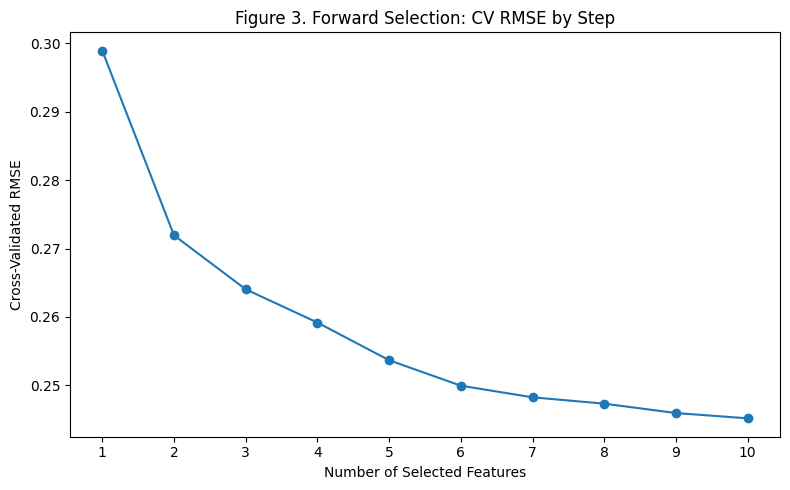

In [11]:
# Figure 3: Forward selection CV RMSE by step
plt.figure(figsize=(8, 5))
plt.plot(forward_history["step"], forward_history["CV_RMSE"], marker="o")
plt.xlabel("Number of Selected Features")
plt.ylabel("Cross-Validated RMSE")
plt.title("Figure 3. Forward Selection: CV RMSE by Step")
plt.xticks(forward_history["step"])
plt.tight_layout()
plt.show()


#### Forward selection interpretation

Forward selection helps me see which variables enter the model first. If the first selected variables are size or shape-related tumor features, that supports my earlier conclusion that these measurements are important for diagnosis.

I also use cross-validation during selection so that I am not just choosing features that fit one training split too closely.

### 1.8 Backward selection

Backward selection does the opposite of forward selection. It starts with all features and removes one feature at a time. At each step, it removes the feature that gives the best cross-validated RMSE after removal.

I use backward selection because it lets me compare a different type of feature selection process. Sometimes forward and backward selection do not choose the exact same features.

In [12]:
def backward_selection(X_data, y_data, min_features=10, cv=None):
    selected_features = list(X_data.columns)
    history = []
    step = 0
    while len(selected_features) > min_features:
        step += 1
        candidate_results = []
        for feature in selected_features:
            trial_features = [f for f in selected_features if f != feature]
            mean_rmse = cv_rmse_for_features(trial_features, X_data, y_data, cv)
            candidate_results.append({
                "step": step,
                "feature_removed": feature,
                "features": trial_features,
                "number_of_features": len(trial_features),
                "CV_RMSE": mean_rmse
            })
        candidate_df = pd.DataFrame(candidate_results).sort_values("CV_RMSE")
        best_row = candidate_df.iloc[0]
        selected_features = best_row["features"]
        history.append({
            "step": step,
            "feature_removed": best_row["feature_removed"],
            "selected_features": selected_features.copy(),
            "number_of_features": len(selected_features),
            "CV_RMSE": best_row["CV_RMSE"]
        })
    return pd.DataFrame(history)
backward_history = backward_selection(X_train, y_train, min_features=10, cv=cv)
backward_history.head()


,step,feature_removed,selected_features,number_of_features,CV_RMSE
0,1,texture_error,"[mean_radius, mean_texture, mean_perimeter, me...",29,0.247241
1,2,symmetry_error,"[mean_radius, mean_texture, mean_perimeter, me...",28,0.244387
2,3,mean_perimeter,"[mean_radius, mean_texture, mean_area, mean_sm...",27,0.243240
3,4,fractal_dimension_error,"[mean_radius, mean_texture, mean_area, mean_sm...",26,0.242250
4,5,mean_fractal_dimension,"[mean_radius, mean_texture, mean_area, mean_sm...",25,0.241404


In [13]:
# Best backward-selection model based on lowest CV RMSE
best_backward_row = backward_history.sort_values("CV_RMSE").iloc[0]
backward_features = best_backward_row["selected_features"]
print("Best number of backward-selected features:", len(backward_features))
print("Backward-selected features:")
print(backward_features)
backward_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
backward_results, backward_train_pred, backward_test_pred = evaluate_model(
    "Backward Selection Linear Regression",
    backward_model,
    X_train[backward_features],
    X_test[backward_features],
    y_train,
    y_test
)
pd.DataFrame([backward_results])


Best number of backward-selected features: 14
Backward-selected features:
['mean_compactness', 'mean_concavity', 'radius_error', 'area_error', 'smoothness_error', 'compactness_error', 'concavity_error', 'concave_points_error', 'worst_radius', 'worst_texture', 'worst_area', 'worst_concavity', 'worst_symmetry', 'worst_fractal_dimension']


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_malignant_at_0.5,precision_malignant_at_0.5
0,Backward Selection Linear Regression,0.211968,0.228106,0.141569,0.156172,0.808013,0.776385,0.982456,0.952381,1.0


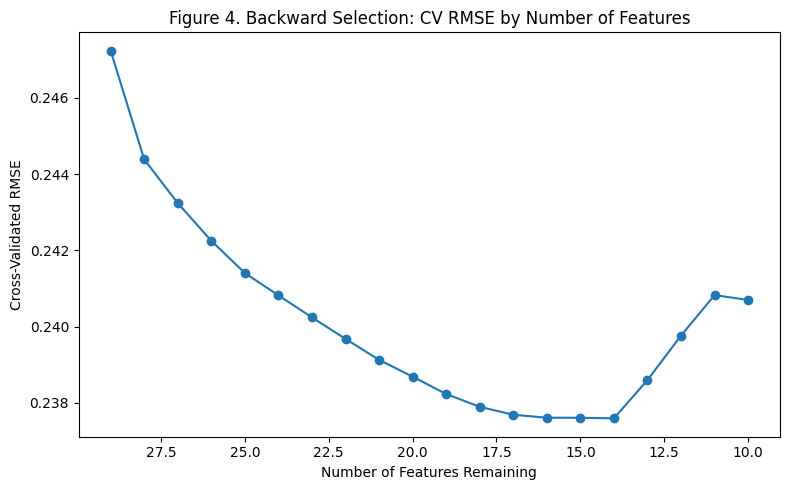

In [14]:
# Figure 4: Backward selection CV RMSE by number of features
plt.figure(figsize=(8, 5))
plt.plot(backward_history["number_of_features"], backward_history["CV_RMSE"], marker="o")
plt.xlabel("Number of Features Remaining")
plt.ylabel("Cross-Validated RMSE")
plt.title("Figure 4. Backward Selection: CV RMSE by Number of Features")
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()


#### Backward selection interpretation

Backward selection is helpful because it starts with the full model and asks which variables can be removed. If the model keeps similar performance after removing many variables, that suggests some predictors are redundant. This would make sense because this dataset has many correlated tumor measurements.

### 1.9 Principal component regression (PCR)

PCR uses PCA to turn the original predictors into principal components, then uses those components in a regression model.

The important idea is that PCR does not choose original variables one by one. Instead, it creates new components that summarize patterns in the predictors.

This is useful here because the dataset has multicollinearity. Many tumor variables overlap, so PCR may be able to summarize them using fewer components.

In [15]:
# Check explained variance from PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
pca = PCA()
pca.fit(X_train_scaled)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
pca_variance_df = pd.DataFrame({
    "component": np.arange(1, len(explained_variance) + 1),
    "explained_variance_ratio": explained_variance,
    "cumulative_variance": cumulative_variance
})
pca_variance_df.head(15)


,component,explained_variance_ratio,cumulative_variance
0,1,0.445935,0.445935
1,2,0.185453,0.631388
2,3,0.095846,0.727234
3,4,0.065938,0.793172
4,5,0.056223,0.849395
5,6,0.039885,0.889280
6,7,0.022145,0.911425
7,8,0.016140,0.927565
8,9,0.012848,0.940412
9,10,0.011657,0.952069


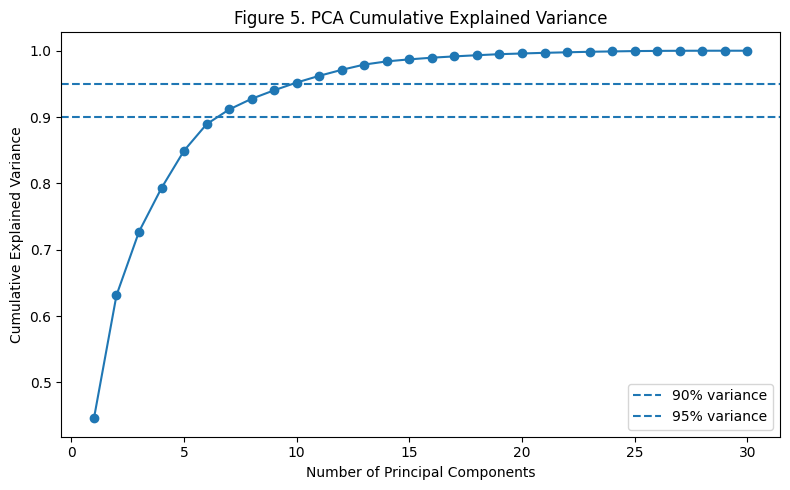

In [16]:
# Figure 5: PCA cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(pca_variance_df["component"], pca_variance_df["cumulative_variance"], marker="o")
plt.axhline(0.90, linestyle="--", label="90% variance")
plt.axhline(0.95, linestyle="--", label="95% variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Figure 5. PCA Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()


#### PCR component tuning

Next, I test different numbers of principal components. I choose the number of components based on cross-validated RMSE.

In [17]:
pcr_results = []
max_components = X_train.shape[1]
for n_components in range(1, max_components + 1):
    pcr_model = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components)),
        ("model", LinearRegression())
    ])
    scores = cross_val_score(
        pcr_model,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_squared_error"
    )
    rmse_scores = np.sqrt(-scores)
    pcr_results.append({
        "n_components": n_components,
        "CV_RMSE_mean": rmse_scores.mean(),
        "CV_RMSE_std": rmse_scores.std()
    })

pcr_results_df = pd.DataFrame(pcr_results)
pcr_results_df.sort_values("CV_RMSE_mean").head(10)


,n_components,CV_RMSE_mean,CV_RMSE_std
26,27,0.247121,0.021900
25,26,0.247267,0.022551
27,28,0.247636,0.021276
28,29,0.248169,0.021445
23,24,0.248390,0.020043
24,25,0.248722,0.022592
22,23,0.249648,0.020650
29,30,0.249957,0.021371
20,21,0.249982,0.021538
21,22,0.250007,0.021142


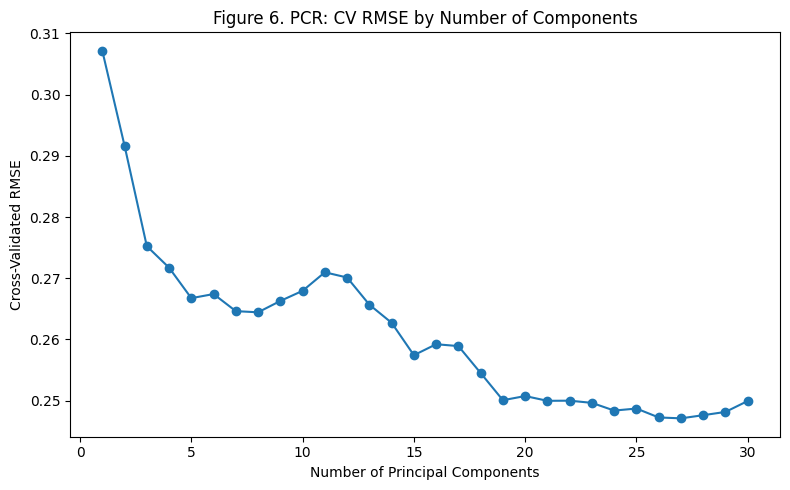

In [18]:
# Figure 6: PCR CV RMSE by number of components
plt.figure(figsize=(8, 5))
plt.plot(pcr_results_df["n_components"], pcr_results_df["CV_RMSE_mean"], marker="o")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cross-Validated RMSE")
plt.title("Figure 6. PCR: CV RMSE by Number of Components")
plt.tight_layout()
plt.show()


In [19]:
best_pcr_components = int(pcr_results_df.sort_values("CV_RMSE_mean").iloc[0]["n_components"])
print("Best number of PCR components:", best_pcr_components)
pcr_best_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=best_pcr_components)),
    ("model", LinearRegression())
])
pcr_results_final, pcr_train_pred, pcr_test_pred = evaluate_model(
    "Principal Component Regression",
    pcr_best_model,
    X_train,
    X_test,
    y_train,
    y_test
)
pd.DataFrame([pcr_results_final])


Best number of PCR components: 27


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_malignant_at_0.5,precision_malignant_at_0.5
0,Principal Component Regression,0.21076,0.231689,0.141827,0.15951,0.810195,0.769305,0.964912,0.904762,1.0


#### PCR interpretation

PCR helps reduce the original 30 features into a smaller number of components. If PCR performs close to the full model, that means much of the useful information can be summarized with fewer dimensions.

One limitation is that PCR components are harder to explain than original variables. For example, it is easier to explain `mean_radius` than "principal component 1."

### 1.10 Partial least squares regression (PLSR)

PLSR is similar to PCR because it also creates components. The difference is that PLSR creates components while considering the target variable.

That matters because PCA only tries to explain variation in the predictors, not necessarily variation related to diagnosis. PLSR may work better when the goal is prediction because it looks for components that are useful for predicting the outcome.

In [20]:
plsr_results = []
max_pls_components = min(X_train.shape[1], X_train.shape[0] - 1)
for n_components in range(1, max_pls_components + 1):
    plsr_model = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", PLSRegression(n_components=n_components))
    ])
    scores = cross_val_score(
        plsr_model,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_squared_error"
    )
    rmse_scores = np.sqrt(-scores)
    plsr_results.append({
        "n_components": n_components,
        "CV_RMSE_mean": rmse_scores.mean(),
        "CV_RMSE_std": rmse_scores.std()
    })
plsr_results_df = pd.DataFrame(plsr_results)
plsr_results_df.sort_values("CV_RMSE_mean").head(10)


,n_components,CV_RMSE_mean,CV_RMSE_std
8,9,0.245673,0.021995
11,12,0.246529,0.022149
18,19,0.246795,0.021945
12,13,0.247206,0.021930
9,10,0.247227,0.023714
13,14,0.247303,0.022466
16,17,0.247364,0.022213
17,18,0.247658,0.022170
19,20,0.247664,0.021732
15,16,0.247722,0.021305


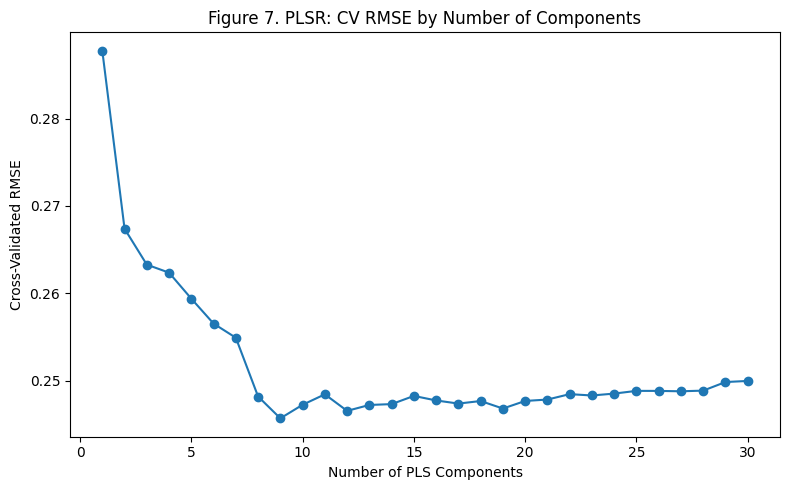

In [21]:
# Figure 7: PLSR CV RMSE by number of components
plt.figure(figsize=(8, 5))
plt.plot(plsr_results_df["n_components"], plsr_results_df["CV_RMSE_mean"], marker="o")
plt.xlabel("Number of PLS Components")
plt.ylabel("Cross-Validated RMSE")
plt.title("Figure 7. PLSR: CV RMSE by Number of Components")
plt.tight_layout()
plt.show()


In [22]:
best_pls_components = int(plsr_results_df.sort_values("CV_RMSE_mean").iloc[0]["n_components"])
print("Best number of PLSR components:", best_pls_components)
plsr_best_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", PLSRegression(n_components=best_pls_components))
])
plsr_results_final, plsr_train_pred, plsr_test_pred = evaluate_model(
    "Partial Least Squares Regression",
    plsr_best_model,
    X_train,
    X_test,
    y_train,
    y_test
)
pd.DataFrame([plsr_results_final])


Best number of PLSR components: 9


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_malignant_at_0.5,precision_malignant_at_0.5
0,Partial Least Squares Regression,0.214209,0.235185,0.144028,0.16123,0.803932,0.762291,0.964912,0.904762,1.0


#### PLSR interpretation

PLSR is useful because it reduces the number of predictors while still paying attention to the diagnosis outcome. If PLSR performs well with fewer components, that suggests the dataset has a smaller number of hidden patterns that are strongly related to malignancy.

### 1.11 Model comparison

Now I compare the baseline model, forward selection, backward selection, PCR, and PLSR.

I am looking at both predictive performance and interpretability.

In [23]:
results_df = pd.DataFrame([
    baseline_results,
    forward_results,
    backward_results,
    pcr_results_final,
    plsr_results_final
])
results_df.sort_values("test_RMSE")


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_malignant_at_0.5,precision_malignant_at_0.5
2,Backward Selection Linear Regression,0.211968,0.228106,0.141569,0.156172,0.808013,0.776385,0.982456,0.952381,1.0
0,Baseline Linear Regression: All Features,0.210002,0.230524,0.140449,0.156241,0.811559,0.771619,0.964912,0.904762,1.0
3,Principal Component Regression,0.210760,0.231689,0.141827,0.159510,0.810195,0.769305,0.964912,0.904762,1.0
4,Partial Least Squares Regression,0.214209,0.235185,0.144028,0.161230,0.803932,0.762291,0.964912,0.904762,1.0
1,Forward Selection Linear Regression,0.221506,0.236456,0.153095,0.167001,0.790348,0.759714,0.956140,0.880952,1.0


In [24]:
# Add model complexity information
complexity_df = pd.DataFrame([
    {
        "model": "Baseline Linear Regression: All Features",
        "complexity": X_train.shape[1],
        "complexity_label": "30 original features"
    },
    {
        "model": "Forward Selection Linear Regression",
        "complexity": len(forward_features),
        "complexity_label": f"{len(forward_features)} selected features"
    },
    {
        "model": "Backward Selection Linear Regression",
        "complexity": len(backward_features),
        "complexity_label": f"{len(backward_features)} selected features"
    },
    {
        "model": "Principal Component Regression",
        "complexity": best_pcr_components,
        "complexity_label": f"{best_pcr_components} components"
    },
    {
        "model": "Partial Least Squares Regression",
        "complexity": best_pls_components,
        "complexity_label": f"{best_pls_components} components"
    }
])
comparison_df = results_df.merge(complexity_df, on="model", how="left")
comparison_df.sort_values("test_RMSE")


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_malignant_at_0.5,precision_malignant_at_0.5,complexity,complexity_label
2,Backward Selection Linear Regression,0.211968,0.228106,0.141569,0.156172,0.808013,0.776385,0.982456,0.952381,1.0,14,14 selected features
0,Baseline Linear Regression: All Features,0.210002,0.230524,0.140449,0.156241,0.811559,0.771619,0.964912,0.904762,1.0,30,30 original features
3,Principal Component Regression,0.210760,0.231689,0.141827,0.159510,0.810195,0.769305,0.964912,0.904762,1.0,27,27 components
4,Partial Least Squares Regression,0.214209,0.235185,0.144028,0.161230,0.803932,0.762291,0.964912,0.904762,1.0,9,9 components
1,Forward Selection Linear Regression,0.221506,0.236456,0.153095,0.167001,0.790348,0.759714,0.956140,0.880952,1.0,10,10 selected features


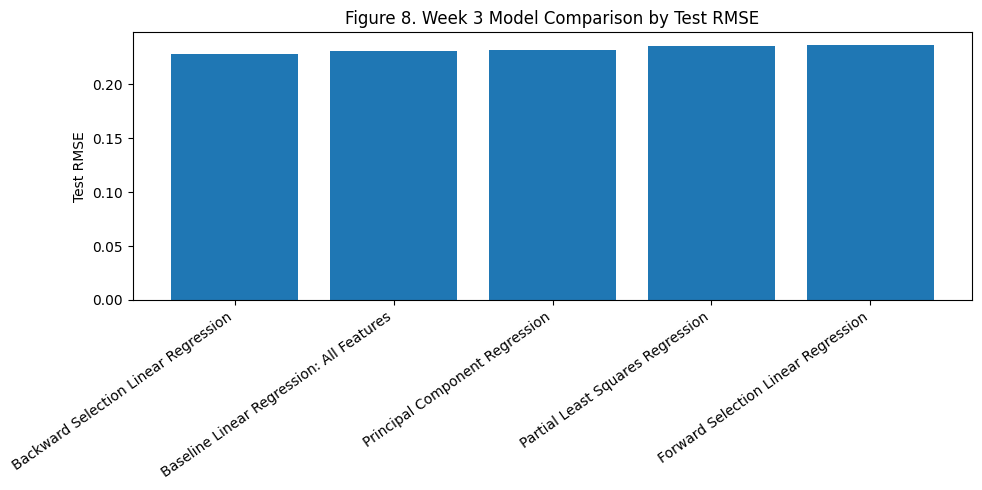

In [25]:
# Figure 8: Test RMSE comparison for Week 3 models
plot_df = comparison_df.sort_values("test_RMSE")
plt.figure(figsize=(10, 5))
plt.bar(plot_df["model"], plot_df["test_RMSE"])
plt.ylabel("Test RMSE")
plt.title("Figure 8. Week 3 Model Comparison by Test RMSE")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


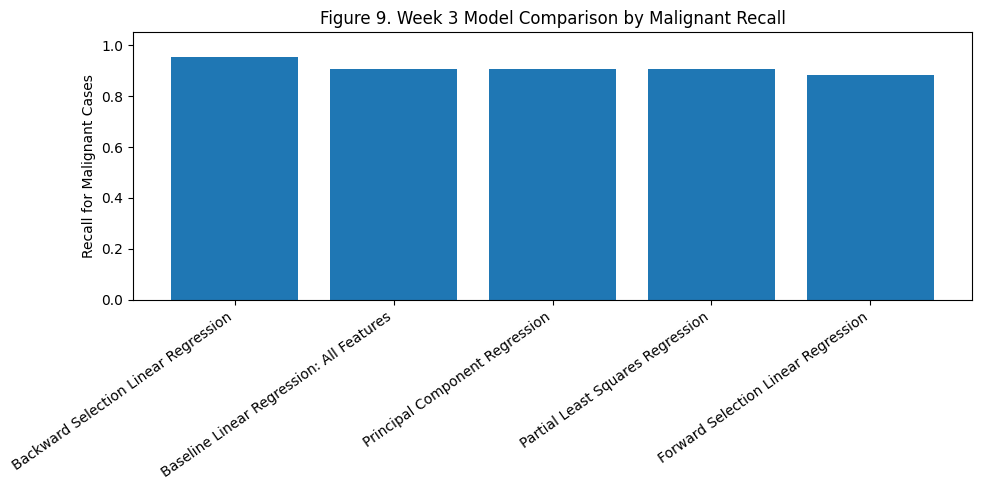

In [26]:
# Figure 9: Malignant recall comparison
plot_df = comparison_df.sort_values("recall_malignant_at_0.5", ascending=False)
plt.figure(figsize=(10, 5))
plt.bar(plot_df["model"], plot_df["recall_malignant_at_0.5"])
plt.ylabel("Recall for Malignant Cases")
plt.title("Figure 9. Week 3 Model Comparison by Malignant Recall")
plt.ylim(0, 1.05)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


### 1.12 Selected feature comparison

This helps me see whether the two feature selection methods agreed with each other.

In [27]:
selected_feature_comparison = pd.DataFrame({
    "feature": sorted(set(forward_features + backward_features))
})
selected_feature_comparison["selected_by_forward"] = selected_feature_comparison["feature"].isin(forward_features)
selected_feature_comparison["selected_by_backward"] = selected_feature_comparison["feature"].isin(backward_features)
selected_feature_comparison


,feature,selected_by_forward,selected_by_backward
0,area_error,True,True
1,compactness_error,True,True
2,concave_points_error,False,True
3,concavity_error,False,True
4,mean_compactness,False,True
5,mean_concavity,False,True
6,radius_error,True,True
7,smoothness_error,False,True
8,worst_area,True,True
9,worst_concave_points,True,False


In [28]:
common_features = sorted(set(forward_features).intersection(set(backward_features)))
print("Features selected by both forward and backward selection:")
for feature in common_features:
    print("-", feature)


Features selected by both forward and backward selection:
- area_error
- compactness_error
- radius_error
- worst_area
- worst_concavity
- worst_radius
- worst_symmetry
- worst_texture


#### Feature selection interpretation

If forward and backward selection choose some of the same variables, those variables may be especially useful. If they choose different variables, that may be because the dataset has correlated predictors. When variables overlap strongly, one selection method might choose radius while another chooses area or perimeter.

### 1.13 Results summary for the milestone

This cell creates a short summary based on the actual output from this notebook. I can use this later when writing Milestone One.

In [29]:
best_model = comparison_df.sort_values("test_RMSE").iloc[0]

print("Week 3 Summary")
print(f"The model with the lowest test RMSE was: {best_model['model']}")
print(f"Test RMSE: {best_model['test_RMSE']:.4f}")
print(f"Test MAE: {best_model['test_MAE']:.4f}")
print(f"Test R²: {best_model['test_R2']:.4f}")
print(f"Recall for malignant cases at 0.50 threshold: {best_model['recall_malignant_at_0.5']:.4f}")
print(f"Model complexity: {best_model['complexity_label']}")

print("\nForward-selected features:")
for feature in forward_features:
    print("-", feature)

print("\nBackward-selected features:")
for feature in backward_features:
    print("-", feature)

print("\nPCR best components:", best_pcr_components)
print("PLSR best components:", best_pls_components)


Week 3 Summary
The model with the lowest test RMSE was: Backward Selection Linear Regression
Test RMSE: 0.2281
Test MAE: 0.1562
Test R²: 0.7764
Recall for malignant cases at 0.50 threshold: 0.9524
Model complexity: 14 selected features

Forward-selected features:
- worst_concave_points
- worst_radius
- worst_texture
- worst_area
- worst_smoothness
- radius_error
- worst_symmetry
- compactness_error
- area_error
- worst_concavity

Backward-selected features:
- mean_compactness
- mean_concavity
- radius_error
- area_error
- smoothness_error
- compactness_error
- concavity_error
- concave_points_error
- worst_radius
- worst_texture
- worst_area
- worst_concavity
- worst_symmetry
- worst_fractal_dimension

PCR best components: 27
PLSR best components: 9


### 1.14 Part 1 summary: Wisconsin

After running the Wisconsin analysis, I learned that there are different ways to simplify a regression model. Forward selection, backward selection, PCR, and PLSR all try to deal with the same general issue, but they do it differently.

The forward selection model started with no variables and added predictors one at a time. This was helpful because I could see which tumor features entered the model first. If size or shape-related features were selected early, that supported my earlier finding that those measurements are important for predicting diagnosis.

The backward selection model started with all variables and removed predictors one at a time. This showed me that the model may not need all 30 features to perform well. Since many variables in this dataset are correlated, removing some features can make the model easier to interpret without necessarily losing much predictive power.

PCR was helpful because it used principal components instead of the original features. This is useful for multicollinearity because correlated variables can be combined into components. The downside is that the components are harder to explain in plain language compared with original tumor measurements like radius or concavity.

PLSR was also helpful because it created components, but it did so while considering the diagnosis outcome. This made PLSR feel more directly connected to prediction than PCR. If PLSR performed well with only a small number of components, that suggests the dataset has a smaller set of hidden patterns that explain much of the relationship between tumor measurements and diagnosis.

To avoid overfitting, I used a train-test split, stratification, scaling inside pipelines, and cross-validation. For forward and backward selection, I used cross-validated RMSE when choosing features. For PCR and PLSR, I used cross-validation to choose the number of components. This helped make the model comparison more fair.

Overall, the Week 3 models supported what I saw in earlier weeks. Tumor measurements are useful for predicting diagnosis, but many of the features overlap with each other. Feature selection methods help identify smaller groups of useful variables, while PCR and PLSR help summarize many related variables into fewer components. This matters for my capstone because I want a model that performs well but is also understandable.

## Part 2 — Breast Cancer Coimbra

The second dataset is the **Breast Cancer Coimbra** dataset. It is also about breast cancer, but it uses a different kind of healthcare information than Wisconsin. Instead of tumor image measurements, it uses clinical and blood-based predictors such as age, BMI, glucose, insulin, HOMA, leptin, adiponectin, resistin, and MCP-1.

I do not merge the two datasets, because they do not share the same patients or the same variables. I run the same Week 3 methods on each dataset separately and compare them in Part 3. Coimbra is also much smaller (116 rows, 9 predictors), which makes it a useful contrast: in Wisconsin these methods mainly address many overlapping image features, while in the smaller Coimbra data they mainly help reduce overfitting risk.

**Setup — repeated imports.** The imports are repeated below so this part can be run on its own, even if the notebook is started from here.

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    recall_score,
    precision_score
)


### 2.1 Load and prepare the data

The Coimbra dataset target is called `Classification`.

The original coding is:

- `1 = Healthy controls`
- `2 = Patients with breast cancer`

For consistency with my Wisconsin analysis, I create:

- `breast_cancer_present = 1` for breast cancer patients
- `breast_cancer_present = 0` for healthy controls

This makes interpretation easier because a higher predicted value means the model is leaning toward breast cancer being present.

In [31]:
coimbra_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00451/dataR2.csv"

coimbra_df = pd.read_csv(coimbra_url)

coimbra_df.columns = (
    coimbra_df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace(".", "_", regex=False)
)

coimbra_df["breast_cancer_present"] = (coimbra_df["Classification"] == 2).astype(int)
coimbra_df["diagnosis_group"] = np.where(coimbra_df["breast_cancer_present"] == 1, "Patient", "Healthy Control")

print("Coimbra dataset shape:", coimbra_df.shape)
print("\nClass counts:")
print(coimbra_df["diagnosis_group"].value_counts())

print("\nMissing values:")
print(coimbra_df.isna().sum())

coimbra_df.head()


Coimbra dataset shape: (116, 12)

Class counts:
diagnosis_group
Patient            64
Healthy Control    52
Name: count, dtype: int64

Missing values:
Age                      0
BMI                      0
Glucose                  0
Insulin                  0
HOMA                     0
Leptin                   0
Adiponectin              0
Resistin                 0
MCP_1                    0
Classification           0
breast_cancer_present    0
diagnosis_group          0
dtype: int64


,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP_1,Classification,breast_cancer_present,diagnosis_group
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,1,0,Healthy Control
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,1,0,Healthy Control
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,1,0,Healthy Control
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,1,0,Healthy Control
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,1,0,Healthy Control


### 2.2 Features and target

The Coimbra dataset is smaller than Wisconsin. It has fewer predictors and fewer rows. Because of that, I expect model results to be less stable than Wisconsin, so cross-validation is especially important.

In [32]:
coimbra_target = "breast_cancer_present"
coimbra_label = "diagnosis_group"

coimbra_features = [
    col for col in coimbra_df.columns
    if col not in ["Classification", coimbra_target, coimbra_label]
]

X_coimbra = coimbra_df[coimbra_features]
y_coimbra = coimbra_df[coimbra_target]

print("Coimbra features:")
print(coimbra_features)

print("\nNumber of rows:", X_coimbra.shape[0])
print("Number of features:", X_coimbra.shape[1])


Coimbra features:
['Age', 'BMI', 'Glucose', 'Insulin', 'HOMA', 'Leptin', 'Adiponectin', 'Resistin', 'MCP_1']

Number of rows: 116
Number of features: 9


### 2.3 Exploratory analysis

Before using forward selection, backward selection, PCR, and PLSR, I want to look at the relationships between the predictors and the outcome. This helps me understand whether feature selection or component methods make sense.

In [33]:
coimbra_group_means = coimbra_df.groupby("diagnosis_group")[coimbra_features].mean().T
coimbra_group_means["difference_patient_minus_control"] = (
    coimbra_group_means["Patient"] - coimbra_group_means["Healthy Control"]
)

coimbra_group_means.sort_values("difference_patient_minus_control")


diagnosis_group,Healthy Control,Patient,difference_patient_minus_control
Age,58.076923,56.671875,-1.405048
BMI,28.317336,26.984740,-1.332596
Adiponectin,10.328205,10.061167,-0.267038
Leptin,26.637933,26.596512,-0.041420
HOMA,1.552398,3.623342,2.070944
Insulin,6.933769,12.513219,5.579450
Resistin,11.614813,17.253777,5.638964
Glucose,88.230769,105.562500,17.331731
MCP_1,499.730692,563.016500,63.285808


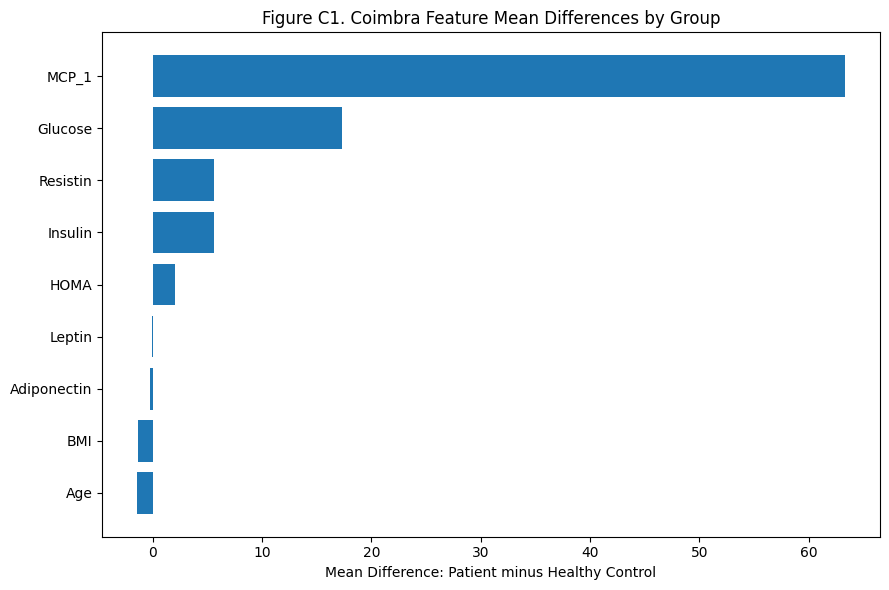

In [34]:
# Figure C1: Coimbra feature mean differences
plot_df = coimbra_group_means.sort_values("difference_patient_minus_control")

plt.figure(figsize=(9, 6))
plt.barh(plot_df.index, plot_df["difference_patient_minus_control"])
plt.xlabel("Mean Difference: Patient minus Healthy Control")
plt.title("Figure C1. Coimbra Feature Mean Differences by Group")
plt.tight_layout()
plt.show()


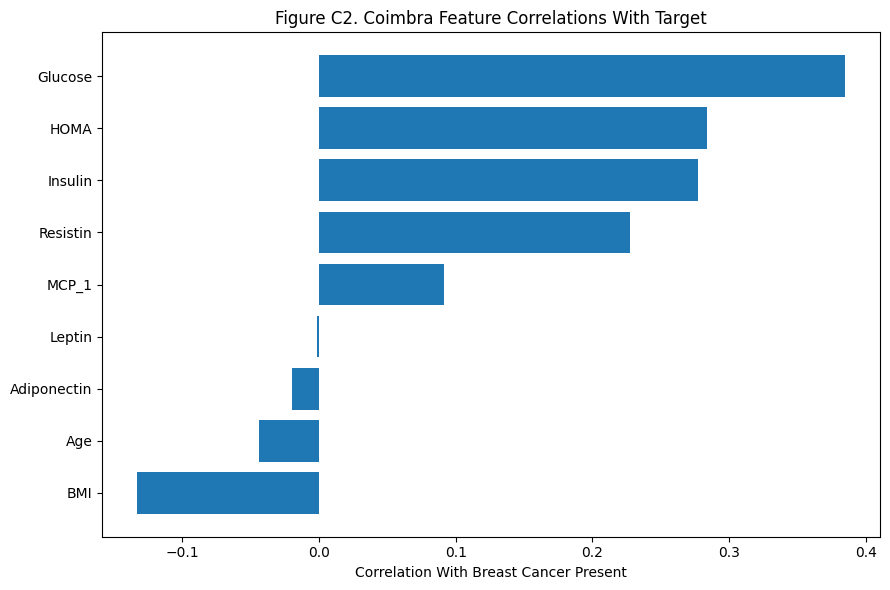

,feature,correlation_with_breast_cancer_present
0,BMI,-0.132586
1,Age,-0.043555
2,Adiponectin,-0.019490
3,Leptin,-0.001078
4,MCP_1,0.091381
5,Resistin,0.227310
6,Insulin,0.276804
7,HOMA,0.284012
8,Glucose,0.384315


In [35]:
# Figure C2: Coimbra correlations with target
coimbra_corr_with_target = coimbra_df[coimbra_features + [coimbra_target]].corr()[coimbra_target].drop(coimbra_target)
coimbra_corr_sorted = coimbra_corr_with_target.sort_values()

plt.figure(figsize=(9, 6))
plt.barh(coimbra_corr_sorted.index, coimbra_corr_sorted.values)
plt.xlabel("Correlation With Breast Cancer Present")
plt.title("Figure C2. Coimbra Feature Correlations With Target")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "feature": coimbra_corr_sorted.index,
    "correlation_with_breast_cancer_present": coimbra_corr_sorted.values
})


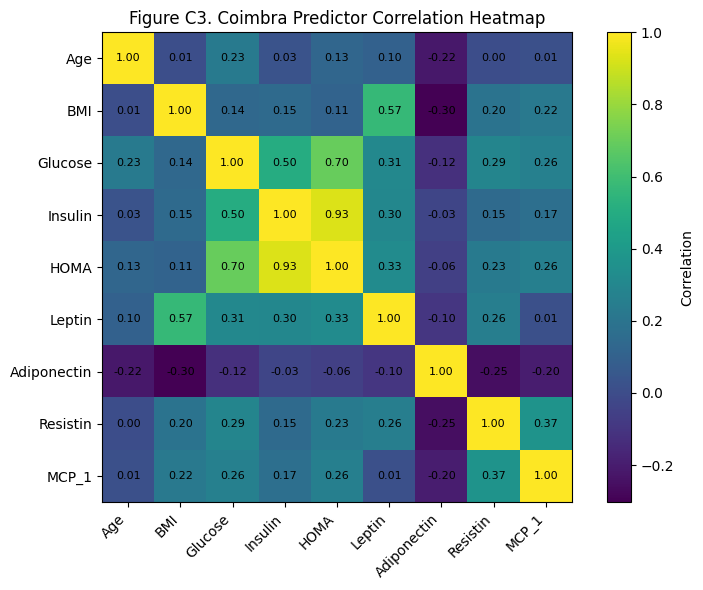

In [36]:
# Figure C3: Coimbra predictor correlation heatmap
coimbra_corr = X_coimbra.corr()

plt.figure(figsize=(8, 6))
plt.imshow(coimbra_corr)
plt.colorbar(label="Correlation")
plt.xticks(range(len(coimbra_corr.columns)), coimbra_corr.columns, rotation=45, ha="right")
plt.yticks(range(len(coimbra_corr.columns)), coimbra_corr.columns)
plt.title("Figure C3. Coimbra Predictor Correlation Heatmap")

for i in range(len(coimbra_corr.columns)):
    for j in range(len(coimbra_corr.columns)):
        plt.text(j, i, f"{coimbra_corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()


#### Coimbra EDA note

The Coimbra dataset is different from Wisconsin because the predictors are not direct tumor measurements. They are clinical and blood-based markers. This makes the analysis interesting because the signal may be weaker or less direct.

The correlation heatmap is important because Week 3 includes feature selection and component methods. If predictors are related to each other, methods like PCR and PLSR may help summarize the data.

### 2.4 Train-test split

I use a stratified train-test split so that both the training and test sets have similar proportions of patients and healthy controls.

Since Coimbra is small, I do not want to rely only on one train-test split, so I also use cross-validation throughout this section.

In [37]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_coimbra,
    y_coimbra,
    test_size=0.20,
    random_state=42,
    stratify=y_coimbra
)

print("Training shape:", X_train_c.shape)
print("Testing shape:", X_test_c.shape)

print("\nTraining target distribution:")
print(y_train_c.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test_c.value_counts(normalize=True).round(3))


Training shape: (92, 9)
Testing shape: (24, 9)

Training target distribution:
breast_cancer_present
1    0.554
0    0.446
Name: proportion, dtype: float64

Testing target distribution:
breast_cancer_present
1    0.542
0    0.458
Name: proportion, dtype: float64


### 2.5 Evaluation functions

I am still using regression-style methods for Week 3, so I evaluate the model using RMSE, MAE, and R². Since the outcome is 0/1, I also check accuracy, recall, and precision using a 0.50 threshold.

For this dataset, recall means the model is correctly identifying breast cancer patients.

In [38]:
def evaluate_predictions_c(y_true, y_pred):
    y_pred = np.asarray(y_pred).ravel()
    y_pred_clipped = np.clip(y_pred, 0, 1)
    y_class = (y_pred_clipped >= 0.50).astype(int)

    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred_clipped)),
        "MAE": mean_absolute_error(y_true, y_pred_clipped),
        "R2": r2_score(y_true, y_pred_clipped),
        "accuracy_at_0.5": accuracy_score(y_true, y_class),
        "recall_patient_at_0.5": recall_score(y_true, y_class, pos_label=1),
        "precision_patient_at_0.5": precision_score(y_true, y_class, pos_label=1, zero_division=0)
    }


def evaluate_model_c(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_metrics = evaluate_predictions_c(y_train, train_pred)
    test_metrics = evaluate_predictions_c(y_test, test_pred)

    results = {
        "model": name,
        "train_RMSE": train_metrics["RMSE"],
        "test_RMSE": test_metrics["RMSE"],
        "train_MAE": train_metrics["MAE"],
        "test_MAE": test_metrics["MAE"],
        "train_R2": train_metrics["R2"],
        "test_R2": test_metrics["R2"],
        "accuracy_at_0.5": test_metrics["accuracy_at_0.5"],
        "recall_patient_at_0.5": test_metrics["recall_patient_at_0.5"],
        "precision_patient_at_0.5": test_metrics["precision_patient_at_0.5"]
    }

    return results, np.clip(np.asarray(train_pred).ravel(), 0, 1), np.clip(np.asarray(test_pred).ravel(), 0, 1)


### 2.6 Baseline linear regression (all features)

I start with a baseline model using all Coimbra predictors. This gives me something to compare against forward selection, backward selection, PCR, and PLSR.

In [39]:
coimbra_baseline_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

coimbra_baseline_results, coimbra_baseline_train_pred, coimbra_baseline_test_pred = evaluate_model_c(
    "Coimbra Baseline Linear Regression: All Features",
    coimbra_baseline_model,
    X_train_c,
    X_test_c,
    y_train_c,
    y_test_c
)

pd.DataFrame([coimbra_baseline_results])


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_patient_at_0.5,precision_patient_at_0.5
0,Coimbra Baseline Linear Regression: All Features,0.399587,0.46818,0.346577,0.40972,0.353685,0.117099,0.75,0.692308,0.818182


### 2.7 Forward selection

Forward selection starts with no predictors and adds one feature at a time. At each step, it chooses the feature that gives the best cross-validated RMSE.

Since Coimbra only has 9 predictors, I let the forward selection process test up to all 9 features.

In [40]:
cv_c = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cv_rmse_for_features_c(feature_list, X_data, y_data, cv):
    model = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])

    scores = cross_val_score(
        model,
        X_data[feature_list],
        y_data,
        cv=cv,
        scoring="neg_mean_squared_error"
    )

    rmse_scores = np.sqrt(-scores)
    return rmse_scores.mean()


def forward_selection_c(X_data, y_data, max_features=None, cv=None):
    if max_features is None:
        max_features = X_data.shape[1]

    remaining_features = list(X_data.columns)
    selected_features = []
    history = []

    for step in range(max_features):
        candidate_results = []

        for feature in remaining_features:
            trial_features = selected_features + [feature]
            mean_rmse = cv_rmse_for_features_c(trial_features, X_data, y_data, cv)

            candidate_results.append({
                "step": step + 1,
                "feature_added": feature,
                "features": trial_features,
                "CV_RMSE": mean_rmse
            })

        candidate_df = pd.DataFrame(candidate_results).sort_values("CV_RMSE")
        best_row = candidate_df.iloc[0]

        selected_features = best_row["features"]
        remaining_features.remove(best_row["feature_added"])

        history.append({
            "step": step + 1,
            "feature_added": best_row["feature_added"],
            "selected_features": selected_features.copy(),
            "CV_RMSE": best_row["CV_RMSE"]
        })

    return pd.DataFrame(history)

coimbra_forward_history = forward_selection_c(X_train_c, y_train_c, max_features=X_train_c.shape[1], cv=cv_c)
coimbra_forward_history


,step,feature_added,selected_features,CV_RMSE
0,1,Glucose,[Glucose],0.466359
1,2,BMI,"[Glucose, BMI]",0.461098
2,3,Insulin,"[Glucose, BMI, Insulin]",0.462739
3,4,HOMA,"[Glucose, BMI, Insulin, HOMA]",0.437675
4,5,Resistin,"[Glucose, BMI, Insulin, HOMA, Resistin]",0.439654
5,6,Leptin,"[Glucose, BMI, Insulin, HOMA, Resistin, Leptin]",0.449640
6,7,Adiponectin,"[Glucose, BMI, Insulin, HOMA, Resistin, Leptin...",0.459164
7,8,MCP_1,"[Glucose, BMI, Insulin, HOMA, Resistin, Leptin...",0.470991
8,9,Age,"[Glucose, BMI, Insulin, HOMA, Resistin, Leptin...",0.486073


In [41]:
best_forward_row_c = coimbra_forward_history.sort_values("CV_RMSE").iloc[0]
coimbra_forward_features = best_forward_row_c["selected_features"]

print("Best number of Coimbra forward-selected features:", len(coimbra_forward_features))
print("Coimbra forward-selected features:")
print(coimbra_forward_features)

coimbra_forward_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

coimbra_forward_results, coimbra_forward_train_pred, coimbra_forward_test_pred = evaluate_model_c(
    "Coimbra Forward Selection Linear Regression",
    coimbra_forward_model,
    X_train_c[coimbra_forward_features],
    X_test_c[coimbra_forward_features],
    y_train_c,
    y_test_c
)

pd.DataFrame([coimbra_forward_results])


Best number of Coimbra forward-selected features: 4
Coimbra forward-selected features:
['Glucose', 'BMI', 'Insulin', 'HOMA']


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_patient_at_0.5,precision_patient_at_0.5
0,Coimbra Forward Selection Linear Regression,0.416069,0.469528,0.366607,0.422489,0.299267,0.112008,0.708333,0.615385,0.8


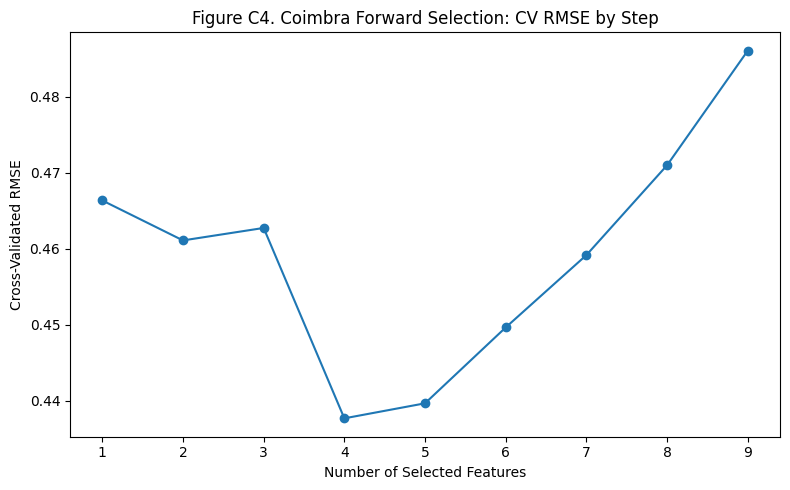

In [42]:
# Figure C4: Coimbra forward selection CV RMSE
plt.figure(figsize=(8, 5))
plt.plot(coimbra_forward_history["step"], coimbra_forward_history["CV_RMSE"], marker="o")
plt.xlabel("Number of Selected Features")
plt.ylabel("Cross-Validated RMSE")
plt.title("Figure C4. Coimbra Forward Selection: CV RMSE by Step")
plt.xticks(coimbra_forward_history["step"])
plt.tight_layout()
plt.show()


#### Coimbra forward selection interpretation

Forward selection helped me see which clinical or blood-based variables entered the model first. If only a few variables give the lowest cross-validated RMSE, that suggests a smaller model may be enough for this dataset.

### 2.8 Backward selection

Backward selection starts with all predictors and removes one feature at a time. At each step, it removes the feature that gives the best cross-validated RMSE after removal.

Because Coimbra has only 9 predictors, I stop when 3 predictors remain.

In [43]:
def backward_selection_c(X_data, y_data, min_features=3, cv=None):
    selected_features = list(X_data.columns)
    history = []
    step = 0

    while len(selected_features) > min_features:
        step += 1
        candidate_results = []

        for feature in selected_features:
            trial_features = [f for f in selected_features if f != feature]
            mean_rmse = cv_rmse_for_features_c(trial_features, X_data, y_data, cv)

            candidate_results.append({
                "step": step,
                "feature_removed": feature,
                "features": trial_features,
                "number_of_features": len(trial_features),
                "CV_RMSE": mean_rmse
            })

        candidate_df = pd.DataFrame(candidate_results).sort_values("CV_RMSE")
        best_row = candidate_df.iloc[0]

        selected_features = best_row["features"]

        history.append({
            "step": step,
            "feature_removed": best_row["feature_removed"],
            "selected_features": selected_features.copy(),
            "number_of_features": len(selected_features),
            "CV_RMSE": best_row["CV_RMSE"]
        })

    return pd.DataFrame(history)

coimbra_backward_history = backward_selection_c(X_train_c, y_train_c, min_features=3, cv=cv_c)
coimbra_backward_history


,step,feature_removed,selected_features,number_of_features,CV_RMSE
0,1,Age,"[BMI, Glucose, Insulin, HOMA, Leptin, Adiponec...",8,0.470991
1,2,Resistin,"[BMI, Glucose, Insulin, HOMA, Leptin, Adiponec...",7,0.455970
2,3,Adiponectin,"[BMI, Glucose, Insulin, HOMA, Leptin, MCP_1]",6,0.447423
3,4,MCP_1,"[BMI, Glucose, Insulin, HOMA, Leptin]",5,0.440760
4,5,Leptin,"[BMI, Glucose, Insulin, HOMA]",4,0.437675
5,6,BMI,"[Glucose, Insulin, HOMA]",3,0.451917


In [44]:
best_backward_row_c = coimbra_backward_history.sort_values("CV_RMSE").iloc[0]
coimbra_backward_features = best_backward_row_c["selected_features"]

print("Best number of Coimbra backward-selected features:", len(coimbra_backward_features))
print("Coimbra backward-selected features:")
print(coimbra_backward_features)

coimbra_backward_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

coimbra_backward_results, coimbra_backward_train_pred, coimbra_backward_test_pred = evaluate_model_c(
    "Coimbra Backward Selection Linear Regression",
    coimbra_backward_model,
    X_train_c[coimbra_backward_features],
    X_test_c[coimbra_backward_features],
    y_train_c,
    y_test_c
)

pd.DataFrame([coimbra_backward_results])


Best number of Coimbra backward-selected features: 4
Coimbra backward-selected features:
['BMI', 'Glucose', 'Insulin', 'HOMA']


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_patient_at_0.5,precision_patient_at_0.5
0,Coimbra Backward Selection Linear Regression,0.416069,0.469528,0.366607,0.422489,0.299267,0.112008,0.708333,0.615385,0.8


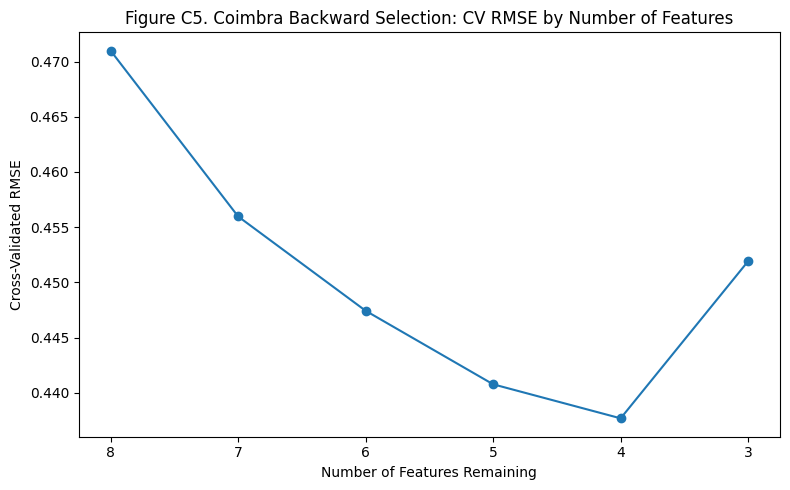

In [45]:
# Figure C5: Coimbra backward selection CV RMSE
plt.figure(figsize=(8, 5))
plt.plot(coimbra_backward_history["number_of_features"], coimbra_backward_history["CV_RMSE"], marker="o")
plt.xlabel("Number of Features Remaining")
plt.ylabel("Cross-Validated RMSE")
plt.title("Figure C5. Coimbra Backward Selection: CV RMSE by Number of Features")
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()


#### Coimbra backward selection interpretation

Backward selection helped me see whether the model could remove some predictors and still perform well. Since this dataset is small, a simpler model may be better because it can reduce overfitting risk.

### 2.9 Principal component regression (PCR)

PCR uses PCA to turn the original predictors into principal components and then uses those components in a regression model.

This is useful if the predictors overlap. For example, glucose, insulin, and HOMA may contain related information.

In [46]:
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)

pca_c = PCA()
pca_c.fit(X_train_c_scaled)

coimbra_explained_variance = pca_c.explained_variance_ratio_
coimbra_cumulative_variance = np.cumsum(coimbra_explained_variance)

coimbra_pca_variance_df = pd.DataFrame({
    "component": np.arange(1, len(coimbra_explained_variance) + 1),
    "explained_variance_ratio": coimbra_explained_variance,
    "cumulative_variance": coimbra_cumulative_variance
})

coimbra_pca_variance_df


,component,explained_variance_ratio,cumulative_variance
0,1,0.325822,0.325822
1,2,0.168667,0.494489
2,3,0.141119,0.635608
3,4,0.124192,0.759801
4,5,0.085038,0.844839
5,6,0.069019,0.913858
6,7,0.051050,0.964909
7,8,0.031630,0.996539
8,9,0.003461,1.000000


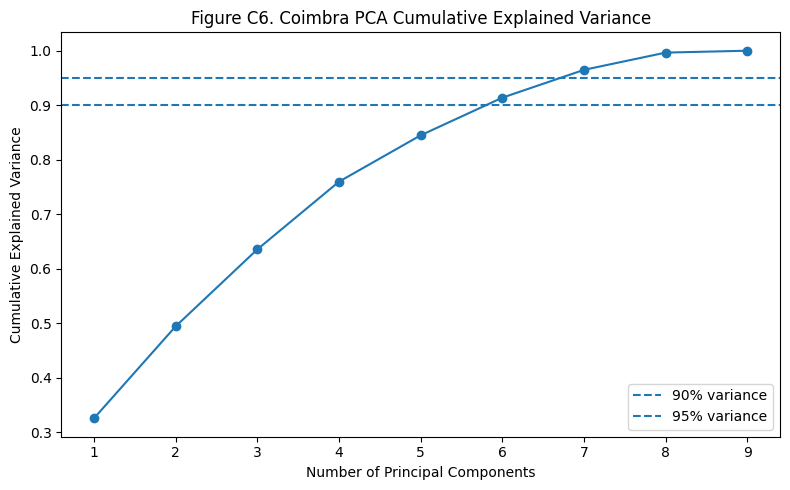

In [47]:
# Figure C6: Coimbra PCA cumulative variance
plt.figure(figsize=(8, 5))
plt.plot(coimbra_pca_variance_df["component"], coimbra_pca_variance_df["cumulative_variance"], marker="o")
plt.axhline(0.90, linestyle="--", label="90% variance")
plt.axhline(0.95, linestyle="--", label="95% variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Figure C6. Coimbra PCA Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()


#### Coimbra PCR component tuning

Now I test different numbers of principal components and choose the number that gives the lowest cross-validated RMSE.

In [48]:
coimbra_pcr_results = []

max_components_c = X_train_c.shape[1]

for n_components in range(1, max_components_c + 1):
    pcr_model_c = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components)),
        ("model", LinearRegression())
    ])

    scores = cross_val_score(
        pcr_model_c,
        X_train_c,
        y_train_c,
        cv=cv_c,
        scoring="neg_mean_squared_error"
    )

    rmse_scores = np.sqrt(-scores)

    coimbra_pcr_results.append({
        "n_components": n_components,
        "CV_RMSE_mean": rmse_scores.mean(),
        "CV_RMSE_std": rmse_scores.std()
    })

coimbra_pcr_results_df = pd.DataFrame(coimbra_pcr_results)
coimbra_pcr_results_df.sort_values("CV_RMSE_mean").head(10)


,n_components,CV_RMSE_mean,CV_RMSE_std
1,2,0.476598,0.018322
2,3,0.481381,0.013963
3,4,0.483294,0.011515
0,1,0.484854,0.016488
8,9,0.486073,0.059000
5,6,0.501035,0.072438
4,5,0.501607,0.049950
6,7,0.516239,0.103662
7,8,0.526715,0.097902


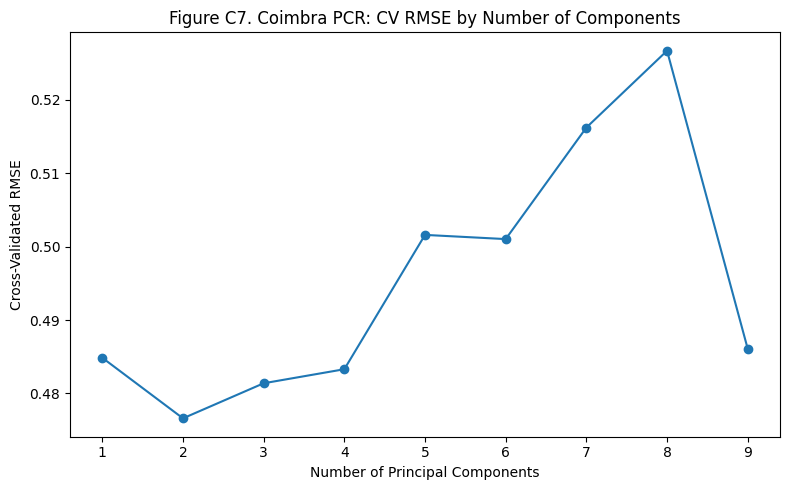

In [49]:
# Figure C7: Coimbra PCR CV RMSE by components
plt.figure(figsize=(8, 5))
plt.plot(coimbra_pcr_results_df["n_components"], coimbra_pcr_results_df["CV_RMSE_mean"], marker="o")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cross-Validated RMSE")
plt.title("Figure C7. Coimbra PCR: CV RMSE by Number of Components")
plt.xticks(coimbra_pcr_results_df["n_components"])
plt.tight_layout()
plt.show()


In [50]:
best_pcr_components_c = int(coimbra_pcr_results_df.sort_values("CV_RMSE_mean").iloc[0]["n_components"])

print("Best number of Coimbra PCR components:", best_pcr_components_c)

coimbra_pcr_best_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=best_pcr_components_c)),
    ("model", LinearRegression())
])

coimbra_pcr_results_final, coimbra_pcr_train_pred, coimbra_pcr_test_pred = evaluate_model_c(
    "Coimbra Principal Component Regression",
    coimbra_pcr_best_model,
    X_train_c,
    X_test_c,
    y_train_c,
    y_test_c
)

pd.DataFrame([coimbra_pcr_results_final])


Best number of Coimbra PCR components: 2


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_patient_at_0.5,precision_patient_at_0.5
0,Coimbra Principal Component Regression,0.468634,0.466369,0.448067,0.442297,0.111027,0.123918,0.625,0.461538,0.75


#### Coimbra PCR interpretation

PCR helped me reduce the Coimbra predictors into components. If a small number of components performs well, that means the clinical markers may share some underlying patterns.

The downside is that components are harder to explain than original variables. For example, it is easier to explain glucose or BMI than "principal component 1."

### 2.10 Partial least squares regression (PLSR)

PLSR also creates components, but unlike PCR, it creates components while considering the outcome variable. This can make PLSR more directly useful for prediction.

This is helpful for Coimbra because I want components that are related to breast cancer status, not just components that explain variation among the predictors.

In [51]:
coimbra_plsr_results = []

max_pls_components_c = X_train_c.shape[1]

for n_components in range(1, max_pls_components_c + 1):
    plsr_model_c = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", PLSRegression(n_components=n_components))
    ])

    scores = cross_val_score(
        plsr_model_c,
        X_train_c,
        y_train_c,
        cv=cv_c,
        scoring="neg_mean_squared_error"
    )

    rmse_scores = np.sqrt(-scores)

    coimbra_plsr_results.append({
        "n_components": n_components,
        "CV_RMSE_mean": rmse_scores.mean(),
        "CV_RMSE_std": rmse_scores.std()
    })

coimbra_plsr_results_df = pd.DataFrame(coimbra_plsr_results)
coimbra_plsr_results_df.sort_values("CV_RMSE_mean").head(10)


,n_components,CV_RMSE_mean,CV_RMSE_std
8,9,0.486073,0.059000
7,8,0.486763,0.057957
0,1,0.488831,0.044387
6,7,0.490926,0.064590
1,2,0.501607,0.079126
5,6,0.504239,0.072644
2,3,0.519969,0.094400
3,4,0.520282,0.097410
4,5,0.523094,0.093991


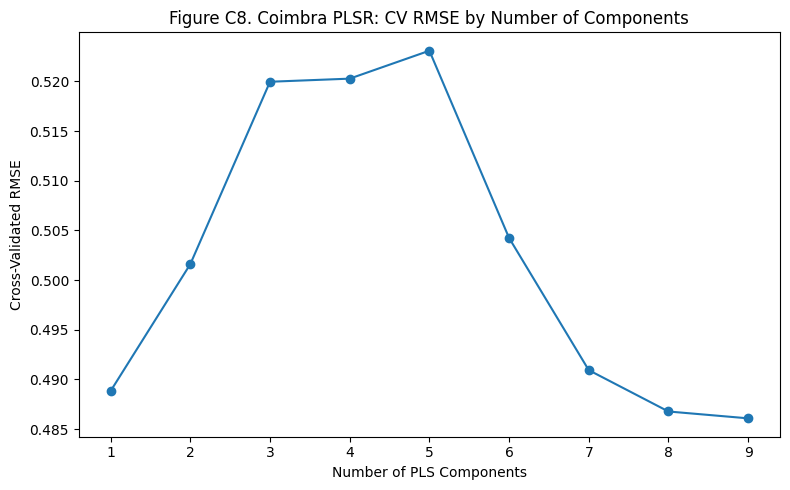

In [52]:
# Figure C8: Coimbra PLSR CV RMSE by components
plt.figure(figsize=(8, 5))
plt.plot(coimbra_plsr_results_df["n_components"], coimbra_plsr_results_df["CV_RMSE_mean"], marker="o")
plt.xlabel("Number of PLS Components")
plt.ylabel("Cross-Validated RMSE")
plt.title("Figure C8. Coimbra PLSR: CV RMSE by Number of Components")
plt.xticks(coimbra_plsr_results_df["n_components"])
plt.tight_layout()
plt.show()


In [53]:
best_pls_components_c = int(coimbra_plsr_results_df.sort_values("CV_RMSE_mean").iloc[0]["n_components"])

print("Best number of Coimbra PLSR components:", best_pls_components_c)

coimbra_plsr_best_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", PLSRegression(n_components=best_pls_components_c))
])

coimbra_plsr_results_final, coimbra_plsr_train_pred, coimbra_plsr_test_pred = evaluate_model_c(
    "Coimbra Partial Least Squares Regression",
    coimbra_plsr_best_model,
    X_train_c,
    X_test_c,
    y_train_c,
    y_test_c
)

pd.DataFrame([coimbra_plsr_results_final])


Best number of Coimbra PLSR components: 9


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_patient_at_0.5,precision_patient_at_0.5
0,Coimbra Partial Least Squares Regression,0.399587,0.46818,0.346577,0.40972,0.353685,0.117099,0.75,0.692308,0.818182


#### Coimbra PLSR interpretation

PLSR was useful because it looked for components that were connected to the target outcome. If PLSR performs better than PCR, that suggests it helped to use the diagnosis information while creating the components.

### 2.11 Model comparison

Now I compare all of the Week 3 models on the Coimbra dataset:

- Baseline linear regression using all features
- Forward selection
- Backward selection
- PCR
- PLSR

In [54]:
coimbra_week3_results_df = pd.DataFrame([
    coimbra_baseline_results,
    coimbra_forward_results,
    coimbra_backward_results,
    coimbra_pcr_results_final,
    coimbra_plsr_results_final
])

coimbra_week3_results_df.sort_values("test_RMSE")


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_patient_at_0.5,precision_patient_at_0.5
3,Coimbra Principal Component Regression,0.468634,0.466369,0.448067,0.442297,0.111027,0.123918,0.625000,0.461538,0.750000
0,Coimbra Baseline Linear Regression: All Features,0.399587,0.468180,0.346577,0.409720,0.353685,0.117099,0.750000,0.692308,0.818182
4,Coimbra Partial Least Squares Regression,0.399587,0.468180,0.346577,0.409720,0.353685,0.117099,0.750000,0.692308,0.818182
2,Coimbra Backward Selection Linear Regression,0.416069,0.469528,0.366607,0.422489,0.299267,0.112008,0.708333,0.615385,0.800000
1,Coimbra Forward Selection Linear Regression,0.416069,0.469528,0.366607,0.422489,0.299267,0.112008,0.708333,0.615385,0.800000


In [55]:
coimbra_complexity_df = pd.DataFrame([
    {
        "model": "Coimbra Baseline Linear Regression: All Features",
        "complexity": X_train_c.shape[1],
        "complexity_label": f"{X_train_c.shape[1]} original features"
    },
    {
        "model": "Coimbra Forward Selection Linear Regression",
        "complexity": len(coimbra_forward_features),
        "complexity_label": f"{len(coimbra_forward_features)} selected features"
    },
    {
        "model": "Coimbra Backward Selection Linear Regression",
        "complexity": len(coimbra_backward_features),
        "complexity_label": f"{len(coimbra_backward_features)} selected features"
    },
    {
        "model": "Coimbra Principal Component Regression",
        "complexity": best_pcr_components_c,
        "complexity_label": f"{best_pcr_components_c} components"
    },
    {
        "model": "Coimbra Partial Least Squares Regression",
        "complexity": best_pls_components_c,
        "complexity_label": f"{best_pls_components_c} components"
    }
])

coimbra_comparison_df = coimbra_week3_results_df.merge(coimbra_complexity_df, on="model", how="left")
coimbra_comparison_df.sort_values("test_RMSE")


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_patient_at_0.5,precision_patient_at_0.5,complexity,complexity_label
3,Coimbra Principal Component Regression,0.468634,0.466369,0.448067,0.442297,0.111027,0.123918,0.625000,0.461538,0.750000,2,2 components
0,Coimbra Baseline Linear Regression: All Features,0.399587,0.468180,0.346577,0.409720,0.353685,0.117099,0.750000,0.692308,0.818182,9,9 original features
4,Coimbra Partial Least Squares Regression,0.399587,0.468180,0.346577,0.409720,0.353685,0.117099,0.750000,0.692308,0.818182,9,9 components
2,Coimbra Backward Selection Linear Regression,0.416069,0.469528,0.366607,0.422489,0.299267,0.112008,0.708333,0.615385,0.800000,4,4 selected features
1,Coimbra Forward Selection Linear Regression,0.416069,0.469528,0.366607,0.422489,0.299267,0.112008,0.708333,0.615385,0.800000,4,4 selected features


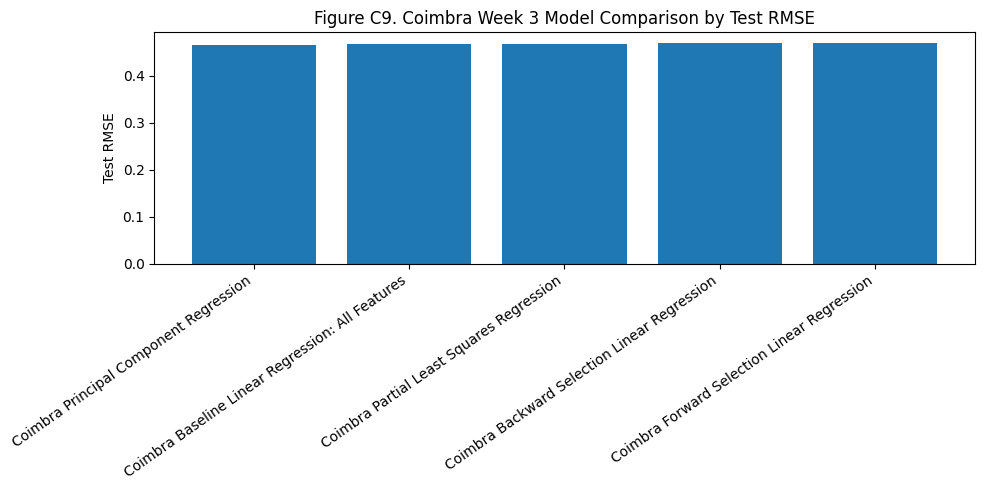

In [56]:
# Figure C9: Coimbra Week 3 test RMSE comparison
plot_df = coimbra_comparison_df.sort_values("test_RMSE")

plt.figure(figsize=(10, 5))
plt.bar(plot_df["model"], plot_df["test_RMSE"])
plt.ylabel("Test RMSE")
plt.title("Figure C9. Coimbra Week 3 Model Comparison by Test RMSE")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


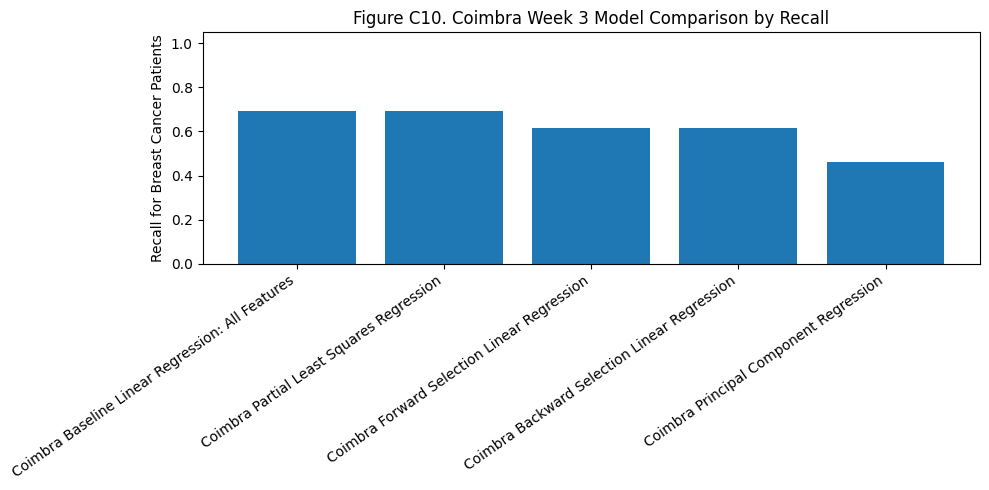

In [57]:
# Figure C10: Coimbra Week 3 recall comparison
plot_df = coimbra_comparison_df.sort_values("recall_patient_at_0.5", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["model"], plot_df["recall_patient_at_0.5"])
plt.ylabel("Recall for Breast Cancer Patients")
plt.title("Figure C10. Coimbra Week 3 Model Comparison by Recall")
plt.ylim(0, 1.05)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


### 2.12 Selected feature comparison

This section compares the features chosen by forward and backward selection.

In [58]:
coimbra_selected_feature_comparison = pd.DataFrame({
    "feature": sorted(set(coimbra_forward_features + coimbra_backward_features))
})

coimbra_selected_feature_comparison["selected_by_forward"] = coimbra_selected_feature_comparison["feature"].isin(coimbra_forward_features)
coimbra_selected_feature_comparison["selected_by_backward"] = coimbra_selected_feature_comparison["feature"].isin(coimbra_backward_features)

coimbra_selected_feature_comparison


,feature,selected_by_forward,selected_by_backward
0,BMI,True,True
1,Glucose,True,True
2,HOMA,True,True
3,Insulin,True,True


In [59]:
coimbra_common_features = sorted(set(coimbra_forward_features).intersection(set(coimbra_backward_features)))

print("Coimbra features selected by both forward and backward selection:")
for feature in coimbra_common_features:
    print("-", feature)


Coimbra features selected by both forward and backward selection:
- BMI
- Glucose
- HOMA
- Insulin


### 2.13 Results summary for the milestone

This cell prints a short summary using the actual results from the Coimbra section. I can use this later when I write Milestone One.

In [60]:
best_coimbra_model = coimbra_comparison_df.sort_values("test_RMSE").iloc[0]

print("Coimbra Week 3 Summary")
print(f"The Coimbra model with the lowest test RMSE was: {best_coimbra_model['model']}")
print(f"Test RMSE: {best_coimbra_model['test_RMSE']:.4f}")
print(f"Test MAE: {best_coimbra_model['test_MAE']:.4f}")
print(f"Test R²: {best_coimbra_model['test_R2']:.4f}")
print(f"Recall for breast cancer patients at 0.50 threshold: {best_coimbra_model['recall_patient_at_0.5']:.4f}")
print(f"Model complexity: {best_coimbra_model['complexity_label']}")

print("\nForward-selected Coimbra features:")
for feature in coimbra_forward_features:
    print("-", feature)

print("\nBackward-selected Coimbra features:")
for feature in coimbra_backward_features:
    print("-", feature)

print("\nCoimbra PCR best components:", best_pcr_components_c)
print("Coimbra PLSR best components:", best_pls_components_c)


Coimbra Week 3 Summary
The Coimbra model with the lowest test RMSE was: Coimbra Principal Component Regression
Test RMSE: 0.4664
Test MAE: 0.4423
Test R²: 0.1239
Recall for breast cancer patients at 0.50 threshold: 0.4615
Model complexity: 2 components

Forward-selected Coimbra features:
- Glucose
- BMI
- Insulin
- HOMA

Backward-selected Coimbra features:
- BMI
- Glucose
- Insulin
- HOMA

Coimbra PCR best components: 2
Coimbra PLSR best components: 9


## Part 3 — Comparison and overall conclusions

### 3.1 Comparison: Wisconsin vs. Coimbra

With both datasets analyzed, I can compare how Week 3 methods worked on two different types of breast cancer data.

The **Wisconsin dataset** has 30 tumor morphology features. Many of those features overlap because radius, perimeter, and area all describe tumor size. Because of that, PCR and PLSR are useful because they can summarize correlated predictors into fewer components. Forward and backward selection are also useful because the model may not need all 30 variables.

The **Coimbra dataset** has only 9 predictors, and they are clinical or blood-based markers. For Coimbra, feature selection is helpful because the dataset is small and simpler models may generalize better. PCR and PLSR are still useful, but the interpretation is different. The goal is not to summarize tumor size measurements but to summarize clinical biomarker patterns.

Overall, Week 3 showed me that model simplification matters in both datasets, but for different reasons. In Wisconsin, simplification helps with many correlated image-based measurements. In Coimbra, simplification helps because the dataset is smaller and the predictors are more indirect.

### 3.2 Overall Week 3 conclusions

Across the two datasets, I found that forward selection, backward selection, PCR, and PLSR can be used for both breast cancer datasets, but the results need to be interpreted differently.

For the Wisconsin dataset, the main issue is redundancy among tumor morphology features. Many variables measure related aspects of tumor size and shape, so feature selection and component methods help simplify the model.

For the Coimbra dataset, the main issue is the smaller sample size and the more indirect nature of the predictors. Clinical and blood-based markers may still help with prediction, but they do not describe the tumor as directly as the Wisconsin features. Because of this, I expect Coimbra models to be less stable and more dependent on cross-validation.

Forward and backward selection helped identify smaller groups of predictors. PCR helped summarize predictor variation into components, while PLSR created components that were more connected to breast cancer status. I found PLSR especially interesting because it is similar to PCR but more focused on prediction.

Overall, adding Coimbra makes the capstone stronger because it allows me to compare image-based tumor measurements with clinical biomarker data. This gives a more complete view of how different types of healthcare data can support breast cancer prediction.

## References

UCI Machine Learning Repository. (n.d.). *Breast Cancer Wisconsin (Diagnostic) dataset*. https://doi.org/10.24432/C5DW2B

Patrício, M., Pereira, J., Crisóstomo, J., Matafome, P., Seiça, R., & Caramelo, F. (2018). *Breast Cancer Coimbra* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52P59

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

Scikit-learn developers. (n.d.). *Principal component analysis*. https://scikit-learn.org/stable/modules/decomposition.html#pca

Scikit-learn developers. (n.d.). *Cross decomposition: PLS regression*. https://scikit-learn.org/stable/modules/cross_decomposition.html